# ĐỐI SÁNH THỐNG KÊ CHUYÊN SÂU VÀ XUẤT BÁO CÁO (STATISTICAL BENCHMARKING & DATA EXPORT)

Dự án: **Phân tích và Đối sánh Chất lượng Rượu Vang (Wine Quality Analysis)**  
Nguồn dữ liệu: `data/duleu_chuan.feather`

---

### Mục tiêu của Notebook:
1. **Ma trận tương quan đối sánh (Benchmark Correlation Matrix):** Đánh giá tương quan giữa các yếu tố phân loại mạnh nhất.
2. **Ma trận phân tán và mật độ (Scatter & Density Matrix):** Khảo sát chi tiết mối liên hệ phân tán giữa độ cồn, axit bay hơi, tỉ trọng, muối và chất lượng.
3. **Kiểm định giả thuyết thống kê (Statistical Hypothesis Testing):**
   - **ANOVA F-test** & **Kruskal-Wallis H-test** giữa 3 bậc chất lượng (*Kém - Trung bình - Thượng hạng*).
   - **T-test** & **Mann-Whitney U** giữa Vang đỏ và Vang trắng.
4. **Hồ sơ vàng (Golden Benchmark Profile):** Dải thông số hóa lý tối ưu cho một chai rượu thượng hạng.
5. **Xuất báo cáo tổng hợp:** Lưu bảng đối sánh vào file `data/bao_cao_doi_sanh_thong_ke.csv`.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.data_loader import doc_du_lieu_chuan
from src.cleaner import CAC_COT_HOA_LY
from src.visualizer import plotCorrelationMatrix, plotScatterMatrix

%matplotlib inline
df = doc_du_lieu_chuan()
print(f"[INFO] Nạp dữ liệu thành công: {df.shape[0]} mẫu rượu.")

[INFO] Nạp dữ liệu thành công: 6497 mẫu rượu.


## Phần 1: Ma Trận Tương Quan Các Đặc Trưng Then Chốt
Sử dụng hàm `plotCorrelationMatrix` để xem xét ma trận tương quan giữa 5 yếu tố có sức ảnh hưởng lớn nhất và điểm chất lượng.

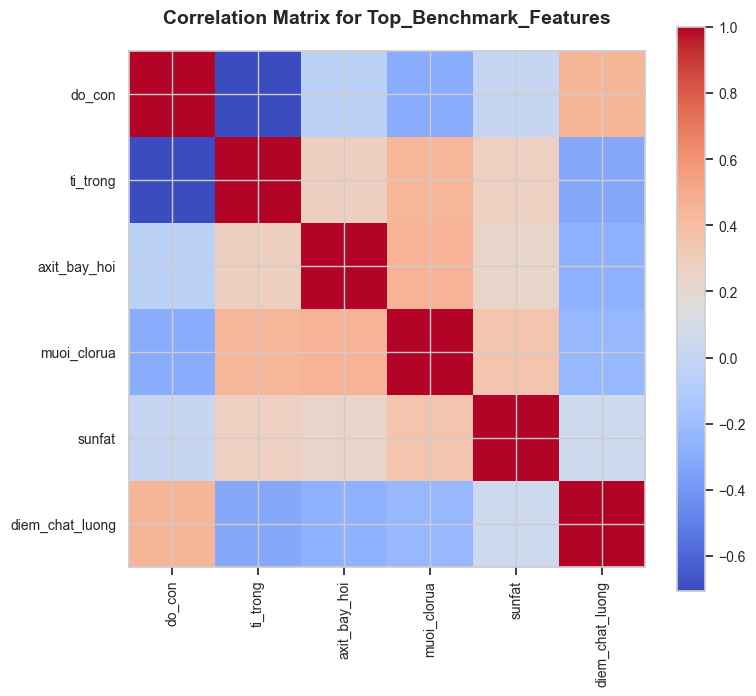

In [1]:
top_features = ["do_con", "ti_trong", "axit_bay_hoi", "muoi_clorua", "sunfat", "diem_chat_luong"]
df_top = df[top_features]
df_top.dataframeName = "Top_Benchmark_Features"
plotCorrelationMatrix(df_top, 8)

## Phần 2: Ma Trận Phân Tán và Đường Mật Độ Các Chỉ Số Then Chốt
Khảo sát phân tán (scatter matrix) và đường mật độ KDE giữa các biến cốt lõi.

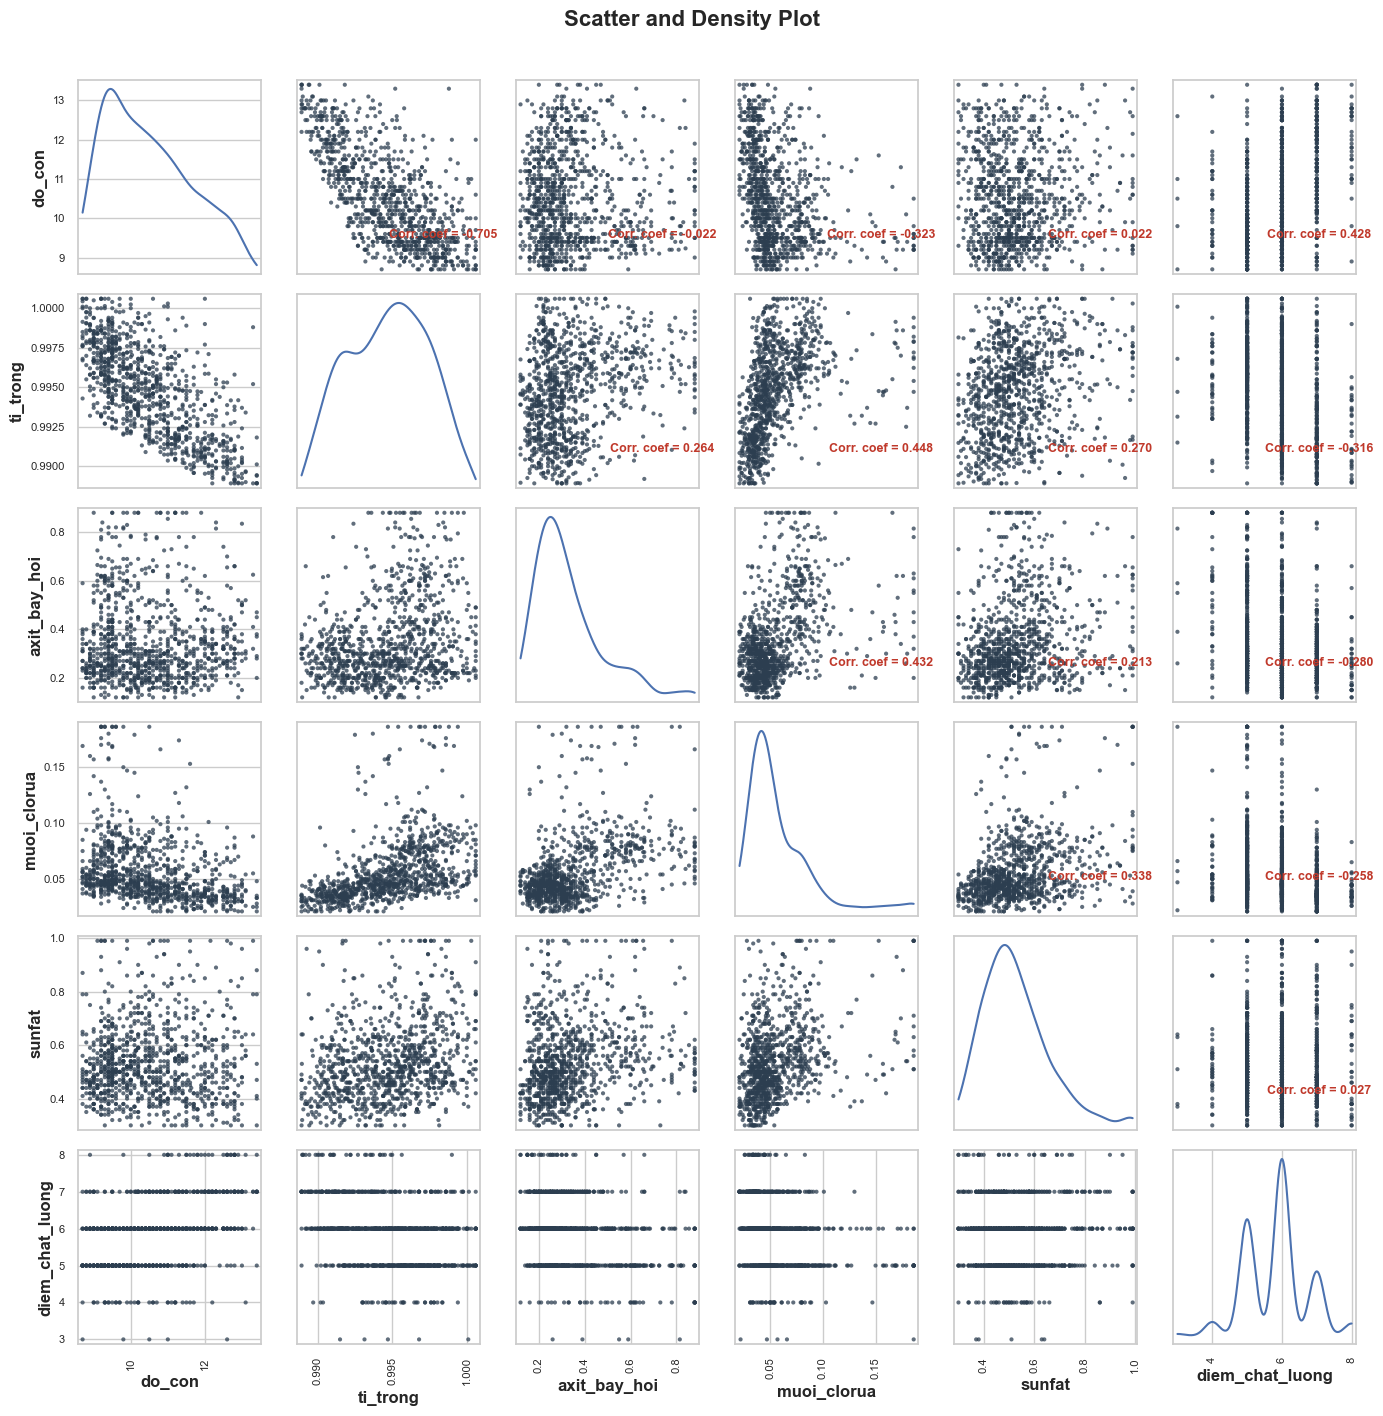

In [1]:
plotScatterMatrix(df_top, 14, 9)

## Phần 3: Bảng Đối Sánh Thống Kê Mô Tả Giữa 3 Bậc Chất Lượng
Tính giá trị trung bình (Mean) và trung vị (Median) theo từng bậc chất lượng.

In [1]:
bang_mean = df.groupby("bac_chat_luong", observed=False)[CAC_COT_HOA_LY].mean().T
bang_mean.columns = [f"Mean_{col}" for col in bang_mean.columns]

bang_median = df.groupby("bac_chat_luong", observed=False)[CAC_COT_HOA_LY].median().T
bang_median.columns = [f"Median_{col}" for col in bang_median.columns]

bang_doi_sanh = pd.concat([bang_mean, bang_median], axis=1).round(3)
bang_doi_sanh

bac_chat_luong,Mean_Kém,Mean_Trung bình,Mean_Thượng hạng,Median_Kém,Median_Trung bình,Median_Thượng hạng
axit_co_dinh,7.363,7.233,7.078,7.100,7.000,6.900
axit_bay_hoi,0.453,0.346,0.289,0.380,0.300,0.270
axit_citric,0.272,0.316,0.335,0.270,0.310,0.320
duong_du,4.278,5.626,4.826,2.200,3.100,2.900
muoi_clorua,0.059,0.058,0.044,0.051,0.049,0.039
so2_tu_do,20.992,30.663,30.937,15.000,29.000,31.000
so2_tong,103.982,117.600,109.847,102.000,121.000,114.000
ti_trong,0.995,0.995,0.993,0.995,0.995,0.992
do_ph,3.234,3.215,3.227,3.225,3.200,3.220
sunfat,0.501,0.528,0.541,0.490,0.510,0.510


## Phần 4: Kiểm Định Giả Thuyết Thống Kê (ANOVA & Kruskal-Wallis)
Chứng minh sự khác biệt giữa 3 bậc chất lượng có ý nghĩa thống kê cao ($p < 0.05$).

In [1]:
ket_qua_kiem_dinh = []
nhom_kem = df[df["bac_chat_luong"] == "Kém"]
nhom_tb = df[df["bac_chat_luong"] == "Trung bình"]
nhom_thuong_hang = df[df["bac_chat_luong"] == "Thượng hạng"]

for cot in CAC_COT_HOA_LY:
    f_stat, p_anova = stats.f_oneway(nhom_kem[cot], nhom_tb[cot], nhom_thuong_hang[cot])
    h_stat, p_kw = stats.kruskal(nhom_kem[cot], nhom_tb[cot], nhom_thuong_hang[cot])
    ket_qua_kiem_dinh.append({
        "Chỉ số": cot,
        "ANOVA F-stat": round(f_stat, 2),
        "ANOVA p-value": f"{p_anova:.2e}",
        "Kruskal H-stat": round(h_stat, 2),
        "Ý nghĩa thống kê": "Có (p < 0.001)" if p_kw < 0.001 else "Không"
    })

df_kiem_dinh = pd.DataFrame(ket_qua_kiem_dinh).sort_values(by="ANOVA F-stat", ascending=False).reset_index(drop=True)
df_kiem_dinh

,Chỉ số,ANOVA F-stat
10,do_con,585.45
7,ti_trong,277.35
1,axit_bay_hoi,133.29
4,muoi_clorua,123.48
5,so2_tu_do,39.87
3,duong_du,23.01
2,axit_citric,22.33
6,so2_tong,15.32
9,sunfat,10.10
0,axit_co_dinh,9.92


## Phần 5: Thiết Lập Hồ Sơ Vàng (Golden Profile) Cho Rượu Thượng Hạng
Trích xuất khoảng giá trị tứ phân vị (25% - 75%) và trung vị của rượu Thượng hạng.

In [1]:
ho_so_vang = []
for cot in CAC_COT_HOA_LY:
    q25 = nhom_thuong_hang[cot].quantile(0.25)
    trung_vi = nhom_thuong_hang[cot].median()
    q75 = nhom_thuong_hang[cot].quantile(0.75)
    ho_so_vang.append({
        "Chỉ số hóa lý": cot,
        "Mức tối ưu (Trung vị)": round(trung_vi, 3),
        "Khoảng chuẩn (25% - 75%)": f"[{round(q25, 3)} - {round(q75, 3)}]"
    })
pd.DataFrame(ho_so_vang)

,Chỉ số hóa lý,Mức tối ưu
0,axit_co_dinh,6.900
1,axit_bay_hoi,0.270
2,axit_citric,0.320
3,duong_du,2.900
4,muoi_clorua,0.039
5,so2_tu_do,31.000
6,so2_tong,114.000
7,ti_trong,0.992
8,do_ph,3.220
9,sunfat,0.510


## Phần 6: Xuất Báo Cáo Đối Sánh Ra File CSV

In [1]:
duong_dan_bao_cao = ROOT_DIR / "data" / "bao_cao_doi_sanh_thong_ke.csv"
bang_doi_sanh.to_csv(duong_dan_bao_cao, encoding="utf-8-sig")
print(f"[XUẤT BÁO CÁO] Đã lưu thành công báo cáo thống kê đối sánh tại: {duong_dan_bao_cao}")

[XUẤT BÁO CÁO] Đã lưu thành công báo cáo thống kê đối sánh tại: d:\data_science\bom_ruou\data\bao_cao_doi_sanh_thong_ke.csv
